In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Matches: (1095, 20)
Deliveries: (260920, 17)


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
matches['winner'].fillna('No Result', inplace=True)
matches.dropna(subset=['city'], inplace=True)

team_rename = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

for col in ['team1', 'team2', 'winner']:
    matches[col] = matches[col].replace(team_rename)

print("Cleaning done ✓")

Cleaning done ✓


In [5]:
win_counts = matches['winner'].value_counts().reset_index()
win_counts.columns = ['team', 'wins']
win_counts = win_counts[win_counts['team'] != 'No Result']

team1_counts = matches['team1'].value_counts()
team2_counts = matches['team2'].value_counts()

total_matches = (team1_counts.add(team2_counts, fill_value=0)).reset_index()
total_matches.columns = ['team', 'matches_played']

win_rate = win_counts.merge(total_matches, on='team')
win_rate['win_rate'] = (win_rate['wins'] / win_rate['matches_played'] * 100).round(2)

win_rate = win_rate.sort_values('win_rate', ascending=False)
win_rate.head()

,team,wins,matches_played,win_rate
8,Gujarat Titans,28,45,62.22
1,Chennai Super Kings,131,225,58.22
0,Mumbai Indians,139,249,55.82
9,Lucknow Super Giants,24,44,54.55
2,Kolkata Knight Riders,128,243,52.67


In [6]:
print("Total matches:", len(matches))
print("Total teams:", matches['team1'].nunique())
print("Total venues:", matches['venue'].nunique())
print("Total deliveries:", len(deliveries))

Total matches: 1044
Total teams: 16
Total venues: 58
Total deliveries: 260920


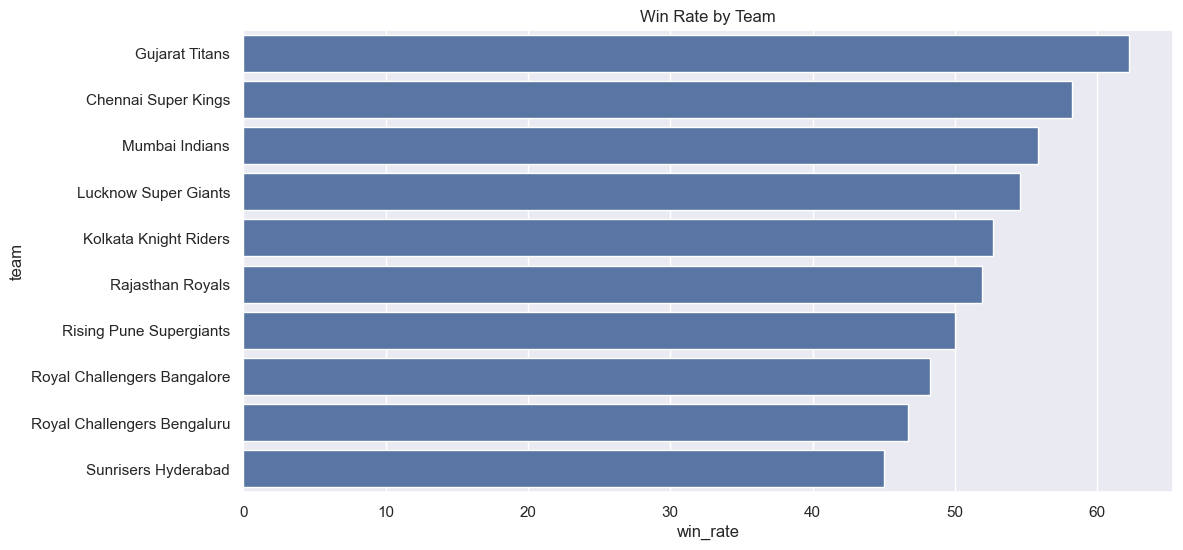

In [7]:
sns.barplot(data=win_rate.head(10), x='win_rate', y='team')
plt.title("Win Rate by Team")
plt.show()

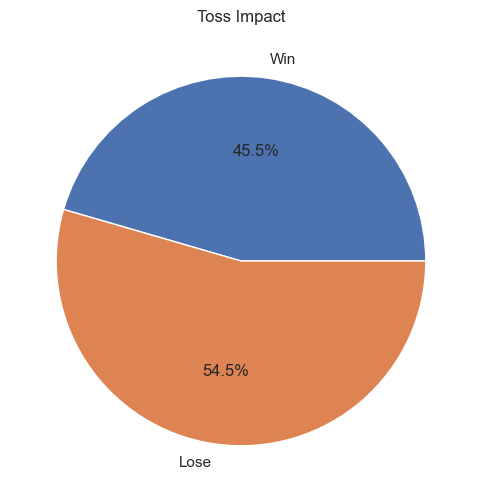

In [8]:
toss_win = matches[matches['toss_winner'] == matches['winner']].shape[0]
toss_lose = matches[matches['toss_winner'] != matches['winner']].shape[0]

plt.pie([toss_win, toss_lose], labels=['Win','Lose'], autopct='%1.1f%%')
plt.title("Toss Impact")
plt.show()

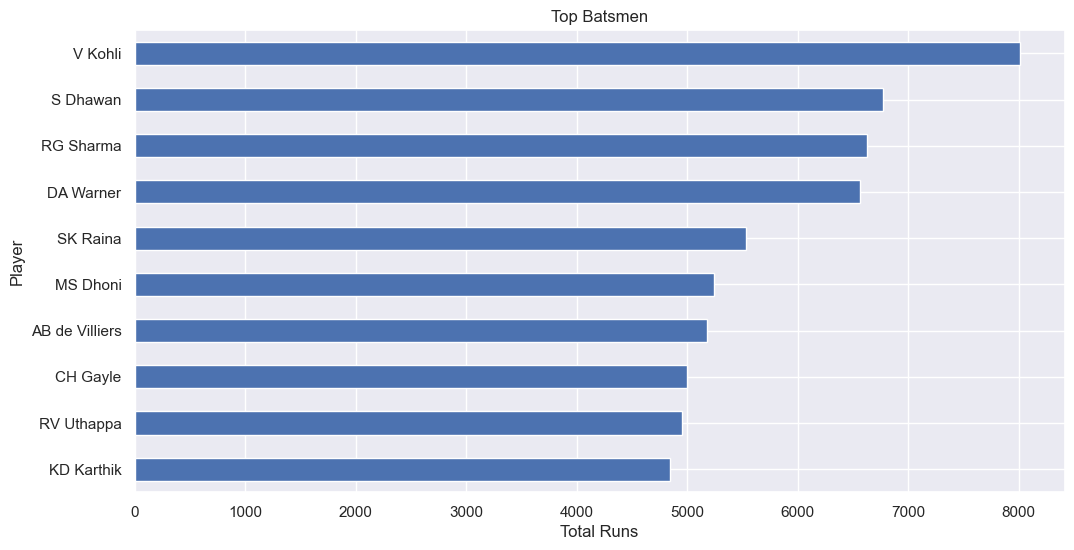

In [9]:
top_batsmen = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_batsmen.plot(kind='barh')

plt.title("Top Batsmen")
plt.xlabel("Total Runs")
plt.ylabel("Player")

plt.gca().invert_yaxis()  # highest on top
plt.show()

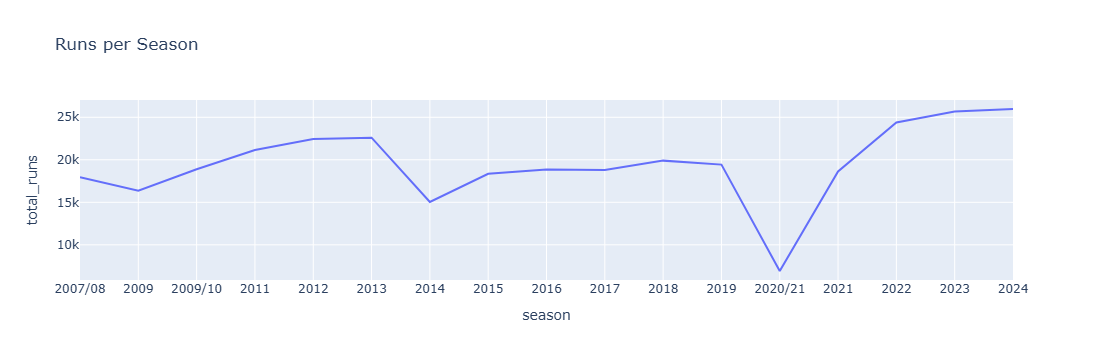

In [10]:
season_runs = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_runs = season_runs.groupby('season')['total_runs'].sum().reset_index()

fig = px.line(season_runs, x='season', y='total_runs', title="Runs per Season")
fig.show()

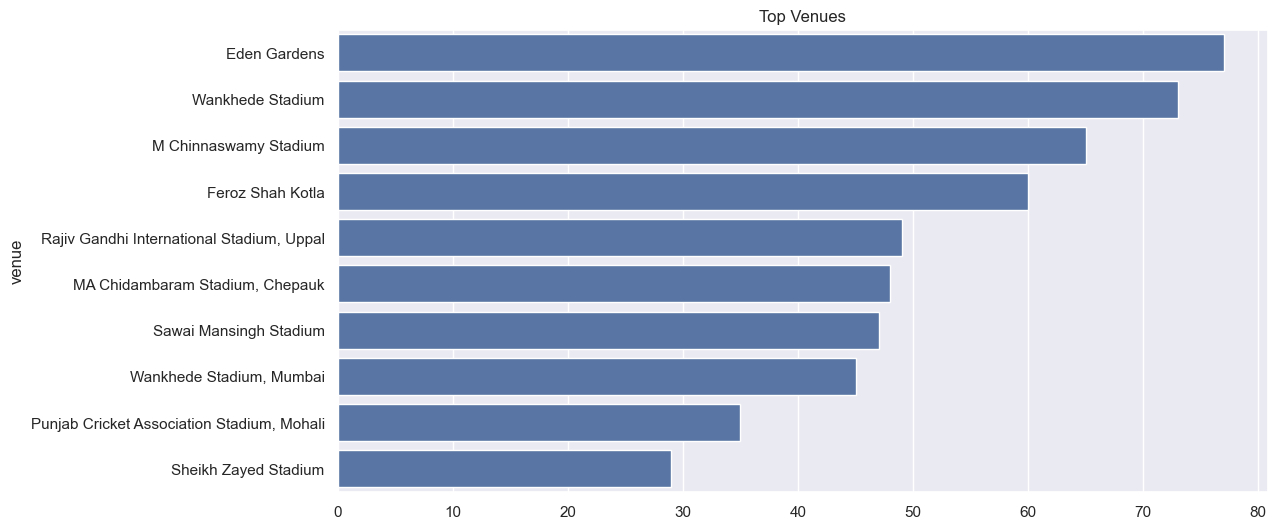

In [11]:
top_venues = matches['venue'].value_counts().head(10)

sns.barplot(x=top_venues.values, y=top_venues.index)
plt.title("Top Venues")
plt.show()

In [12]:
conn = sqlite3.connect(':memory:')
matches.to_sql('matches', conn, index=False)
deliveries.to_sql('deliveries', conn, index=False)

query = "SELECT winner, COUNT(*) as wins FROM matches GROUP BY winner ORDER BY wins DESC LIMIT 5"
pd.read_sql_query(query, conn)

,winner,wins
0,Mumbai Indians,139
1,Chennai Super Kings,131
2,Kolkata Knight Riders,128
3,Sunrisers Hyderabad,109
4,Royal Challengers Bangalore,109


In [13]:
ml_data = matches[['toss_decision','venue','season','toss_winner','winner']].copy()
ml_data = ml_data[ml_data['winner'] != 'No Result']

ml_data['toss_won_match'] = (ml_data['toss_winner'] == ml_data['winner']).astype(int)

In [14]:
le = LabelEncoder()

ml_data['toss_decision_enc'] = le.fit_transform(ml_data['toss_decision'])
ml_data['venue_enc'] = le.fit_transform(ml_data['venue'])

ml_data['season'] = ml_data['season'].astype(str).str[:4].astype(int)

X = ml_data[['toss_decision_enc','venue_enc','season']]
y = ml_data['toss_won_match']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [15]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4951923076923077


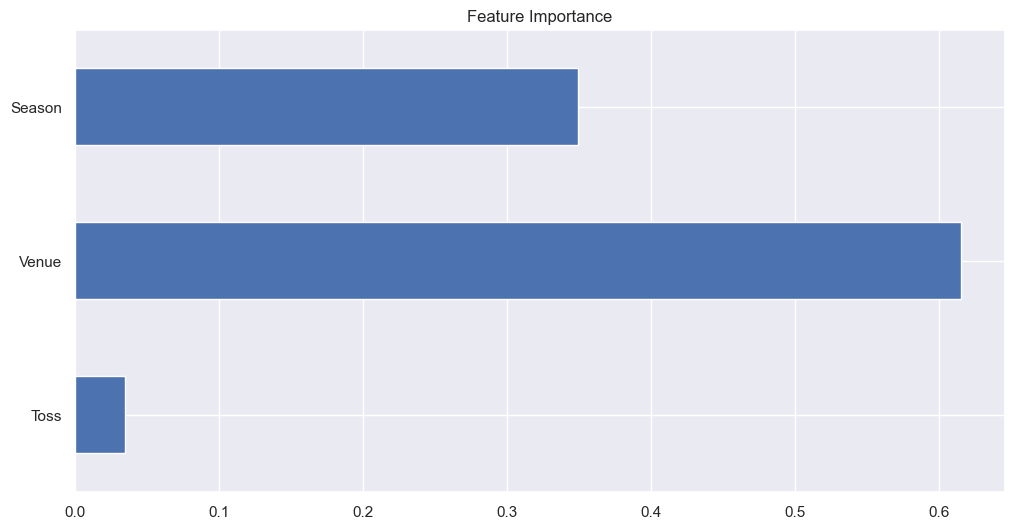

In [17]:
importances = pd.Series(model.feature_importances_, index=['Toss','Venue','Season'])
importances.plot(kind='barh')
plt.title("Feature Importance")
plt.show()